Instantiate package dependencies so the code is run with the exact package versions:

In [1]:
using Pkg
Pkg.instantiate()

Load required packages

In [2]:
using BenchmarkingEconomicEfficiency, CSV, DataFrames

Import data

In [3]:
df = DataFrame(CSV.File("DataBanks2years.csv"))

Row,BankNumber,Long Name,BankName,Y1FININV06,Y1FININV07,Y1FININV08,Y1FININV09,Y1FININV10,Y2LOANS06,Y2LOANS07,Y2LOANS08,Y2LOANS09,Y2LOANS10,X1FINFUNDS06,X1FINFUNDS07,X1FINFUNDS08,X1FINFUNDS09,X1FINFUNDS10,X2LABOR06,X2LABOR07,X2LABOR08,X2LABOR09,X2LABOR10,X3CAPITAL06,X3CAPITAL07,X3CAPITAL08,X3CAPITAL09,X3CAPITAL10,P1FININV06,P1FININV07,P1FININV08,P1FININV09,P1FININV10,P2LOANS06,P2LOANS07,P2LOANS08,P2LOANS09,P2LOANS10,W1FINFUNDS06,W1FINFUNDS07,W1FINFUNDS08,W1FINFUNDS09,W1FINFUNDS10,W2LABOR06,W2LABOR07,W2LABOR08,W2LABOR09,W2LABOR10,W3CAPITAL06,W3CAPITAL07,W3CAPITAL08,W3CAPITAL09,W3CAPITAL10
,Int64,String31,String31,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,Export-Import Bank,Export-Import Bank,8064,2222,3137,3211,3125,61785,71372,78622,82866,81996,26162,25128,25349,22990,25019,203,207,205,205,202,494,487,481,478,505,0.0001,0.0005,0.0131,0.0078,0.0099,0.0494,0.0449,0.0362,0.0182,0.0125,0.0776,0.0846,0.0705,0.0327,0.0186,1.7931,1.7729,1.761,1.7756,1.7178,0.2935,0.2669,0.2723,0.272,0.2455
2,2,Bank of Taiwan,Bank of Taiwan,276949,239645,217155,194182,904580,1488234,1925883,1999742,2058748,2091100,2133665,2465672,2947330,3189111,3171493,6791,8217,8125,8061,7951,74448,82011,79931,78452,76576,0.0287,0.034,0.0329,0.0243,0.0093,0.0267,0.0279,0.0308,0.0162,0.0156,0.0252,0.023,0.0194,0.0096,0.0077,1.455,1.3969,1.3946,1.3893,1.434,0.0631,0.0762,0.0784,0.0703,0.073
3,3,Taipei Fubon Bank,Taipei Fubon Bank,108841,115083,104619,81800,392491,617985,662278,758269,835739,866282,888453,877014,1014222,1135907,1222499,6092,6259,6549,6145,6434,13404,13262,12975,12386,12082,0.1731,0.072,0.0725,0.0578,0.0132,0.0318,0.0339,0.0321,0.0171,0.0164,0.0137,0.0186,0.0169,0.007,0.005,0.8551,0.9192,0.9495,0.9937,1.0036,0.4696,0.5008,0.5079,0.5001,0.5901
4,4,Bank of Kaohsiung,Bank of Kaohsiung,30733,27940,18567,15287,16740,99567,112496,138424,139665,163054,121315,130499,159665,161921,189169,857,887,939,923,914,2984,2932,2346,2285,2237,0.028,0.0321,0.0384,0.0192,0.0243,0.0315,0.0315,0.0297,0.0176,0.0156,0.0163,0.0158,0.0157,0.0083,0.0055,1.2941,1.31,1.2599,1.2784,1.3895,0.1883,0.1988,0.2634,0.2398,0.2499
5,5,Land Bank,Land Bank,240812,194304,233576,255176,227086,1369330,1449698,1563891,1593615,1706964,1481201,1548524,1681447,1745395,1846028,5742,5782,5813,5957,5732,47797,45993,23070,22872,22634,0.0129,0.0166,0.0121,0.0089,0.0141,0.0291,0.0301,0.0316,0.0182,0.0166,0.0186,0.0213,0.0217,0.0089,0.0066,1.6703,1.4728,1.4576,1.3601,1.4656,0.1031,0.1055,0.2091,0.1868,0.1937
6,6,Cooperative Bank,Cooperative Bank,167760,347608,298342,412985,502569,1734526,1745691,1848838,1814493,1799753,1900844,1982102,2060957,2149455,2220071,8463,8803,8916,9002,8835,33993,33864,34032,33868,33638,0.0357,0.0194,0.0203,0.0103,0.0074,0.0256,0.0301,0.0309,0.0194,0.0177,0.0173,0.019,0.0193,0.0089,0.007,1.2661,1.3445,1.3891,1.389,1.4538,0.1585,0.1802,0.1814,0.1708,0.1699
7,7,First Bank,First Bank,341503,318170,337611,516476,507630,979893,1079681,1169533,1108130,1260072,1389180,1446747,1400668,1531093,1602733,7074,7021,7144,7038,7048,23386,23601,23212,22793,22843,0.0198,0.026,0.0241,0.0103,0.0099,0.0328,0.0334,0.0324,0.0196,0.0175,0.0161,0.0182,0.0178,0.0075,0.0049,1.2289,1.2659,1.3172,1.2889,1.3422,0.2094,0.2176,0.217,0.208,0.2078
8,8,Hua Nan Bank,Hua Nan Bank,175867,201389,332461,423501,393020,1030505,1063760,1133780,1117043,1256618,1316426,1333171,1414955,1537165,1595039,7220,7054,7195,7073,7126,22481,23000,23912,23106,24907,0.0554,0.0514,0.0322,0.0141,0.0137,0.0307,0.0333,0.0324,0.0187,0.0162,0.0159,0.0175,0.0159,0.0072,0.0053,1.2205,1.2869,1.2418,1.2876,1.3305,0.2383,0.2432,0.2324,0.2175,0.2005
9,9,Chang Hwa Bank,Chang Hwa Bank,256027,194842,222366,274348,257105,875145,921046,991595,102356

Describe the data

In [4]:
describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,BankNumber,16.0,1,16.0,31,0,Int64
2,Long Name,,Bank SinoPac,,Union Bank,0,String31
3,BankName,,Bank SinoPac,,Union Bank,0,String31
4,Y1FININV06,1.11098e5,2354,83272.0,352976,0,Int64
5,Y1FININV07,1.11285e5,888,69597.0,347608,0,Int64
6,Y1FININV08,1.18212e5,1109,80517.0,440462,0,Int64
7,Y1FININV09,1.36879e5,1171,71350.0,516476,0,Int64
8,Y1FININV10,1.96808e5,1681,157870.0,904580,0,Int64
9,Y2LOANS06,5.06372e5,49780,244739.0,1734526,0,Int64


Extract inputs, outputs, inputs' prices and outputs' prices for 2006 and 2010

In [5]:
X06 = [df.X1FINFUNDS06 df.X2LABOR06 df.X3CAPITAL06]
X10 = [df.X1FINFUNDS10 df.X2LABOR10 df.X3CAPITAL10]
Y06 = [df.Y1FININV06 df.Y2LOANS06]
Y10 = [df.Y1FININV10 df.Y2LOANS10]
W06 = [df.W1FINFUNDS06 df.W2LABOR06 df.W3CAPITAL06]
W10 = [df.W1FINFUNDS10 df.W2LABOR10 df.W3CAPITAL10]
P06 = [df.P1FININV06 df.P2LOANS06]
P10 = [df.P1FININV10 df.P2LOANS10];
banks = df.BankName;

Build 3D arrays with time periods on the third dimension:

In [6]:
n = size(X06, 1) # Number of DMUs
m = size(X06, 2) # Number of inputs
s = size(Y06, 2) # Number of outputs

X = Array{Float64,3}(undef, n, m, 2);
X[:, :, 1] = X06;
X[:, :, 2] = X10;

Y = Array{Float64,3}(undef, n, s, 2);
Y[:, :, 1] = Y06;
Y[:, :, 2] = Y10;

W = Array{Float64,3}(undef, n, m, 2);
W[:, :, 1] = W06;
W[:, :, 2] = W10;

P = Array{Float64,3}(undef, n, s, 2);
P[:, :, 1] = P06;
P[:, :, 2] = P10;

# 3. Measuring and decomposing profit inefficiency change

## 3.1 The Russell inefficiency measure

In [7]:
deaprofitchangerussell(X, Y, W, P, names = banks, monetary = true)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Profit Efficiency Change Russell DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Orientation = Graph; Returns to Scale = VRS
───────────────────────────────────────────────────────────────────────────────────────────
                        Prof.Change      Tech.Change     Alloc.Change    NF.Base    NF.Comp
───────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank        0.0062458     -0.000722062       0.00696786      4.032    154.688
Bank of Taiwan        19170.2            0.00513775    19170.2         23488.3    27950.2
Taipei Fubon Bank     36617.8         8718.93          27898.9         26046.3    25904.4
Bank of Kaohsiung      5287.41         462.021          4825.39         2809.44    2033.91
Land Bank              4677.51           0.00229801     4677.5         15532.4    16009.6
Cooperative Bank       3851.75           0.0023035      3851.75        26939.5    18595.1
First Bank             6385.87          

In [8]:
deaprofitrussell(X10, Y10, W10, P10, names = banks, monetary = true)

Russell Profit DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2
Orientation = Graph; Returns to Scale = VRS
───────────────────────────────────────────────────────────────────
                            Profit        Technical      Allocative
───────────────────────────────────────────────────────────────────
Export-Import Bank      0.00471509      0.000744436      0.00397065
Bank of Taiwan       5032.68            0.000130703   5032.68
Taipei Fubon Bank    5714.51            0.00604251    5714.51
Bank of Kaohsiung    9963.17          649.928         9313.25
Land Bank               0.00220981      0.000825393      0.00138442
Cooperative Bank     5318.08            0.00057239    5318.08
First Bank           5660.85            0.000410325   5660.85
Hua Nan Bank         6002.52         3110.28          2892.24
Chang Hwa Bank       8580.09         4072.53          4507.56
Mega Bank               0.00243368      0.000480792      0.00195289
Cathay United Bank  27122.4         11071.7          

In [9]:
deaprofitrussell(X10, Y10, W10, P10, names = banks, monetary = false)

Russell Profit DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2
Orientation = Graph; Returns to Scale = VRS
──────────────────────────────────────────────────────────
                          Profit   Technical    Allocative
──────────────────────────────────────────────────────────
Export-Import Bank    3.04814e-5  4.81252e-6    2.56689e-5
Bank of Taiwan        0.180059    4.67629e-9    0.180059
Taipei Fubon Bank     0.2206      2.33262e-7    0.2206
Bank of Kaohsiung     4.89853     0.319546      4.57899
Land Bank             1.38031e-7  5.15563e-8    8.64747e-8
Cooperative Bank      0.285995    3.07818e-8    0.285995
First Bank            0.238513    1.72886e-8    0.238513
Hua Nan Bank          0.240396    0.124565      0.115832
Chang Hwa Bank        0.444959    0.211199      0.23376
Mega Bank             9.60067e-8  1.89668e-8    7.70398e-8
Cathay United Bank    0.820204    0.334818      0.485386
The Shanghai Bank     1.34696     0.153611      1.19335
Union Bank           25.1122     

In [10]:
dearussell(X10, Y10, orient = :Graph, rts = :VRS, names = banks)

Russell DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2
Orientation = Graph; Returns to Scale = VRS
───────────────────────────────────────────────────────────────────────────────
                    efficiency     effX1     effX2      effX3    effY1    effY2
───────────────────────────────────────────────────────────────────────────────
Export-Import Bank    0.999995  1.0       1.0       0.999997   1.00002  1.0
Bank of Taiwan        1.0       1.0       1.0       1.0        1.0      1.0
Taipei Fubon Bank     1.0       1.0       0.999999  1.0        1.0      1.0
Bank of Kaohsiung     0.680454  0.714658  0.623644  0.653934   2.43882  1.0
Land Bank             1.0       1.0       1.0       1.0        1.0      1.0
Cooperative Bank      1.0       1.0       1.0       1.0        1.0      1.0
First Bank            1.0       1.0       1.0       1.0        1.0      1.0
Hua Nan Bank          0.875435  0.960964  0.776303  0.639911   1.0      1.0
Chang Hwa Bank        0.788801  1.0       0.64816   0.

## 3.2 The Weighted Additive Distance Function

In [11]:
deaprofitchangeadd(X, Y, W, P, :MIP, monetary = true, names = banks)

Profit Efficiency Change Additive DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Weights = MIP; Returns to Scale = VRS
─────────────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change       Tech.Change      Alloc.Change     NF.Base    NF.Comp
─────────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0             4.62704e-14      -4.62704e-14      0.8064    30.9375
Bank of Taiwan       19170.2            -8.34717e-13   19170.2           4697.67    5590.05
Taipei Fubon Bank    36617.8         10994.4           25623.3           5209.27    5180.88
Bank of Kaohsiung     5287.41         -571.466          5858.88           561.887    406.782
Land Bank             4677.5             1.52886e-12    4677.5           3106.47    3201.91
Cooperative Bank      3851.75           -1.73383e-12    3851.75          5387.89    3719.01
First Bank            6385.

## 3.3 The Enhanced Russell Graph (or Slack-Based Measure) inefficiency measure

In [12]:
deaprofitchangeerg(X, Y, W, P, monetary = true, names = banks)

Profit Efficiency Change Enhanced Russell Graph Slack Based Measure DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Returns to Scale = VRS
─────────────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change       Tech.Change      Alloc.Change     NF.Base    NF.Comp
─────────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0             2.64037e-14      -2.64037e-14      1.6128     61.875
Bank of Taiwan       19170.2             3.72372e-12   19170.2          14093.0     16770.1
Taipei Fubon Bank    36617.8         12956.1           23661.6          22255.8     10361.8
Bank of Kaohsiung     5287.41          268.986          5018.42          4179.92     3665.06
Land Bank             4677.5            -7.10967e-13    4677.5           6212.95     6403.83
Cooperative Bank      3851.75            1.32983e-12    3851.75         11978.1      7438.02
First 

## 3.4 The Directional Distance Function

In [13]:
deaprofitchange(X, Y, W, P, Gx = :Monetary, Gy = :Monetary,  names = banks)

Profit Efficiency Change DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Returns to Scale = VRS
Gx = Monetary; Gy = Monetary
───────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change      Tech.Change      Alloc.Change  NF.Base  NF.Comp
───────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0            4.28309e-14      -4.28309e-14      1.0      1.0
Bank of Taiwan       19170.2            1.68769e-13   19170.2              1.0      1.0
Taipei Fubon Bank    36617.8         5290.52          31327.3              1.0      1.0
Bank of Kaohsiung     5287.41         -24.3168         5311.73             1.0      1.0
Land Bank             4677.5           -1.23947e-14    4677.5              1.0      1.0
Cooperative Bank      3851.75          -2.03394e-12    3851.75             1.0      1.0
First Bank            6385.87           1.49253e-13    6385.87     

In [14]:
deaprofit(X10, Y10, W10, P10, Gx = :Monetary, Gy = :Monetary,  names = banks)

Profit DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2
Returns to Scale = VRS
Gx = Monetary; Gy = Monetary
────────────────────────────────────────────────────────────────────
                             Profit       Technical       Allocative
────────────────────────────────────────────────────────────────────
Export-Import Bank      0.0             2.73529e-14     -2.73529e-14
Bank of Taiwan       5032.68           -2.86972e-13   5032.68
Taipei Fubon Bank    5714.51            1.83669e-14   5714.51
Bank of Kaohsiung    9963.17          724.56          9238.61
Land Bank               6.54836e-11     3.9531e-14       6.54441e-11
Cooperative Bank     5318.08           -6.58941e-14   5318.08
First Bank           5660.84           -4.62454e-14   5660.84
Hua Nan Bank         6002.52         3524.78          2477.74
Chang Hwa Bank       8580.09         4012.62          4567.46
Mega Bank              -3.63798e-12    -8.0143e-13      -2.83655e-12
Cathay United Bank  27122.4          4766.64   

In [15]:
GxGymon = 1 ./ (sum(P10, dims = 2) + sum(W10, dims = 2));
Gxmon = repeat(GxGymon, 1, m);
Gymon = repeat(GxGymon, 1, s);

deaddf(X10, Y10, Gx = Gxmon, Gy = Gymon, rts = :VRS, names = banks)

Directional DF DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2
Returns to Scale = VRS
Gx = Custom; Gy = Custom
───────────────────────────────────────────────────────────────────────────────────────────────────────────────
                        efficiency          slackX1   slackX2         slackX3          slackY1          slackY2
───────────────────────────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank     2.73529e-14      0.0             0.0       0.0             -7.90747e-12      0.0
Bank of Taiwan        -2.86972e-13     -1.25388e-10     0.0      -1.70033e-11      0.0              0.0
Taipei Fubon Bank      1.83669e-14      4.02086e-12     0.0       0.0              0.0              0.0
Bank of Kaohsiung    724.56         68495.1             0.0       0.0              0.0              0.0
Land Bank              3.9531e-14      -1.30223e-10     0.0       0.0              0.0              0.0
Cooperative Bank      -6.58941e-14 

## 3.5. The Hölder Distance Function

In [16]:
deaprofitchangeholder(X, Y, W, P, l = Inf, weight = true, monetary = true, names = banks)

Profit Efficiency Change Hölder DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
l = Inf; Returns to Scale = VRS
──────────────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change      Tech.Change      Alloc.Change        NF.Base   NF.Comp
──────────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0            2.22499e-13      -2.22499e-13   5592.14        1992.21
Bank of Taiwan       19170.2            1.34928e-12   19170.2              1.16031e5  82446.0
Taipei Fubon Bank    36617.8        11639.0           24978.8          62167.9        39087.2
Bank of Kaohsiung     5287.41         873.455          4413.96          7645.25        5819.88
Land Bank             4677.5           -2.17529e-13    4677.5          85023.0        56506.3
Cooperative Bank      3851.75          -2.78528e-12    3851.75         99380.4        69674.6
First Bank           

# 3.6 The Modified Directional Distance Function

In [17]:
deaprofitchangemddf(X, Y, W, P, Gx = :Observed, Gy =  :Observed,  monetary = true, names = banks)

┌ Warning: DMU 29 termination status: TIME_LIMIT. Primal status: FEASIBLE_POINT. Dual status: NO_SOLUTION
└ @ DataEnvelopmentAnalysis /Users/javierbarbero/.julia/packages/DataEnvelopmentAnalysis/mWqvg/src/deamddf.jl:180


Profit Efficiency Change Modified DDF DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Returns to Scale = VRS
Gx = Observed; Gy = Observed
───────────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change     Tech.Change     Alloc.Change     NF.Base     NF.Comp
───────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0           1.0649e-13       -1.0649e-13   2030.17      465.353
Bank of Taiwan       19170.2           9.60694e-15   19170.2          7948.44     8412.59
Taipei Fubon Bank    36617.8        5435.3           31182.5         12171.8      5180.88
Bank of Kaohsiung     5287.41        719.073          4568.34         1977.43     1040.43
Land Bank             4677.5           1.80234e-13    4677.5         27550.3     12183.8
Cooperative Bank      3851.75         -1.98767e-12    3851.75        32884.6     15540.5
First Bank            6385.87  

# 3.7 The Reverse Directional Distance Function

In [18]:
deaprofitchangerddf(X, Y, W, P, :MDDF, Gx = :Observed, Gy = :Observed, monetary = true, names = banks)

┌ Warning: DMU 29 termination status: TIME_LIMIT. Primal status: INFEASIBLE_POINT. Dual status: NO_SOLUTION
└ @ DataEnvelopmentAnalysis /Users/javierbarbero/.julia/packages/DataEnvelopmentAnalysis/mWqvg/src/deamddf.jl:180
┌ Warning: DMU 29 termination status: TIME_LIMIT. Primal status: INFEASIBLE_POINT. Dual status: NO_SOLUTION
└ @ DataEnvelopmentAnalysis /Users/javierbarbero/.julia/packages/DataEnvelopmentAnalysis/mWqvg/src/deamddf.jl:180


Profit Efficiency Change Reverse DDF DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Returns to Scale = VRS
Associated efficiency measure = MDDF
───────────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change      Tech.Change      Alloc.Change    NF.Base    NF.Comp
───────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0           -3.58176e-14       3.58176e-14   2030.17     465.353
Bank of Taiwan       19170.2            3.53743e-13   19170.2           7948.44    8412.59
Taipei Fubon Bank    36617.8        17188.7           19429.1          38492.3     5180.88
Bank of Kaohsiung     5287.41        1146.78           4140.63          3996.88    2950.42
Land Bank             4677.5            1.088e-13      4677.5          27550.3    12183.8
Cooperative Bank      3851.75          -1.98793e-12    3851.75         32884.6    15540.5
First Bank        

# 3.8 The General Direct Approach

In [19]:
deaprofitchangegda(X, Y, W, P, :ERG, monetary = true, names = banks)

General Direct Approach Profit Efficiency Change DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2; Time periods = 2
Returns to Scale = VRS
Associated efficiency measure = ERG
──────────────────────────────────────────────────────────────────────────────────────────────
                       Prof.Change       Tech.Change       Alloc.Change     NF.Base    NF.Comp
──────────────────────────────────────────────────────────────────────────────────────────────
Export-Import Bank       0.0             2.64037e-14        2.27374e-13      1.6128     61.875
Bank of Taiwan       19170.2             3.72372e-12    19170.2          14093.0     16770.1
Taipei Fubon Bank    36617.8         24935.5            11682.3          42833.6     10361.8
Bank of Kaohsiung     5287.41         1101.36            4186.05          5319.71     3695.01
Land Bank             4677.5            -7.10967e-13     4677.5           6212.95     6403.83
Cooperative Bank      3851.75            1.32983e-12     3851.75         1

# 4. Measuring and decomposing profitability efficiency

In [20]:
deaprofitabilitychange(X, Y, W, P, alpha = 0.5, names = banks)

Profitability Change DEA Model 
DMUs = 31; Inputs = 3; Outputs = 2
alpha = 0.5; Returns to Scale = VRS
───────────────────────────────────────────────────────────────────────────────────
                    Prof.Change  CRS.Change  VRS.Change  Scale.Change  Alloc.Change
───────────────────────────────────────────────────────────────────────────────────
Export-Import Bank     1.0         1.0         1.0           1.0           0.999999
Bank of Taiwan         1.66464     1.32712     1.0           1.32712       1.25433
Taipei Fubon Bank      3.85488     1.60141     1.45932       1.09737       2.40718
Bank of Kaohsiung      1.31061     1.09678     1.16201       0.943861      1.19496
Land Bank              1.06771     1.02118     1.0           1.02118       1.04557
Cooperative Bank       1.50486     0.997407    1.0           0.997407      1.50877
First Bank             1.18441     1.23893     1.0           1.23893       0.955992
Hua Nan Bank           1.9465      1.24239     1.19621       1

# 6. Empirical results: Profit inefficiency change of Taiwanese banks

Load required package:

In [21]:
using StatsPlots
using XLSX

Calculate and store all models:

In [22]:
drussel = deaprofitchangerussell(X, Y, W, P, monetary = true, names = banks)
dadd = deaprofitchangeadd(X, Y, W, P, :MIP, monetary = true, names = banks)
derg = deaprofitchangeerg(X, Y, W, P, monetary = true, names = banks)
dddf = deaprofitchange(X, Y, W, P, Gx = :Monetary, Gy = :Monetary,  names = banks)
dholder = deaprofitchangeholder(X, Y, W, P, l = Inf, weight = true, monetary = true, names = banks)
dmddf = deaprofitchangemddf(X, Y, W, P, Gx = :Observed, Gy =  :Observed,  monetary = true, names = banks)
drddf = deaprofitchangerddf(X, Y, W, P, :MDDF, Gx = :Observed, Gy = :Observed, monetary = true, names = banks)
dgda = deaprofitchangegda(X, Y, W, P, :ERG, monetary = true, names = banks);

┌ Warning: DMU 29 termination status: TIME_LIMIT. Primal status: INFEASIBLE_POINT. Dual status: NO_SOLUTION
└ @ DataEnvelopmentAnalysis /Users/javierbarbero/.julia/packages/DataEnvelopmentAnalysis/mWqvg/src/deamddf.jl:180
┌ Warning: DMU 29 termination status: TIME_LIMIT. Primal status: INFEASIBLE_POINT. Dual status: NO_SOLUTION
└ @ DataEnvelopmentAnalysis /Users/javierbarbero/.julia/packages/DataEnvelopmentAnalysis/mWqvg/src/deamddf.jl:180
┌ Warning: DMU 29 termination status: TIME_LIMIT. Primal status: INFEASIBLE_POINT. Dual status: NO_SOLUTION
└ @ DataEnvelopmentAnalysis /Users/javierbarbero/.julia/packages/DataEnvelopmentAnalysis/mWqvg/src/deamddf.jl:180


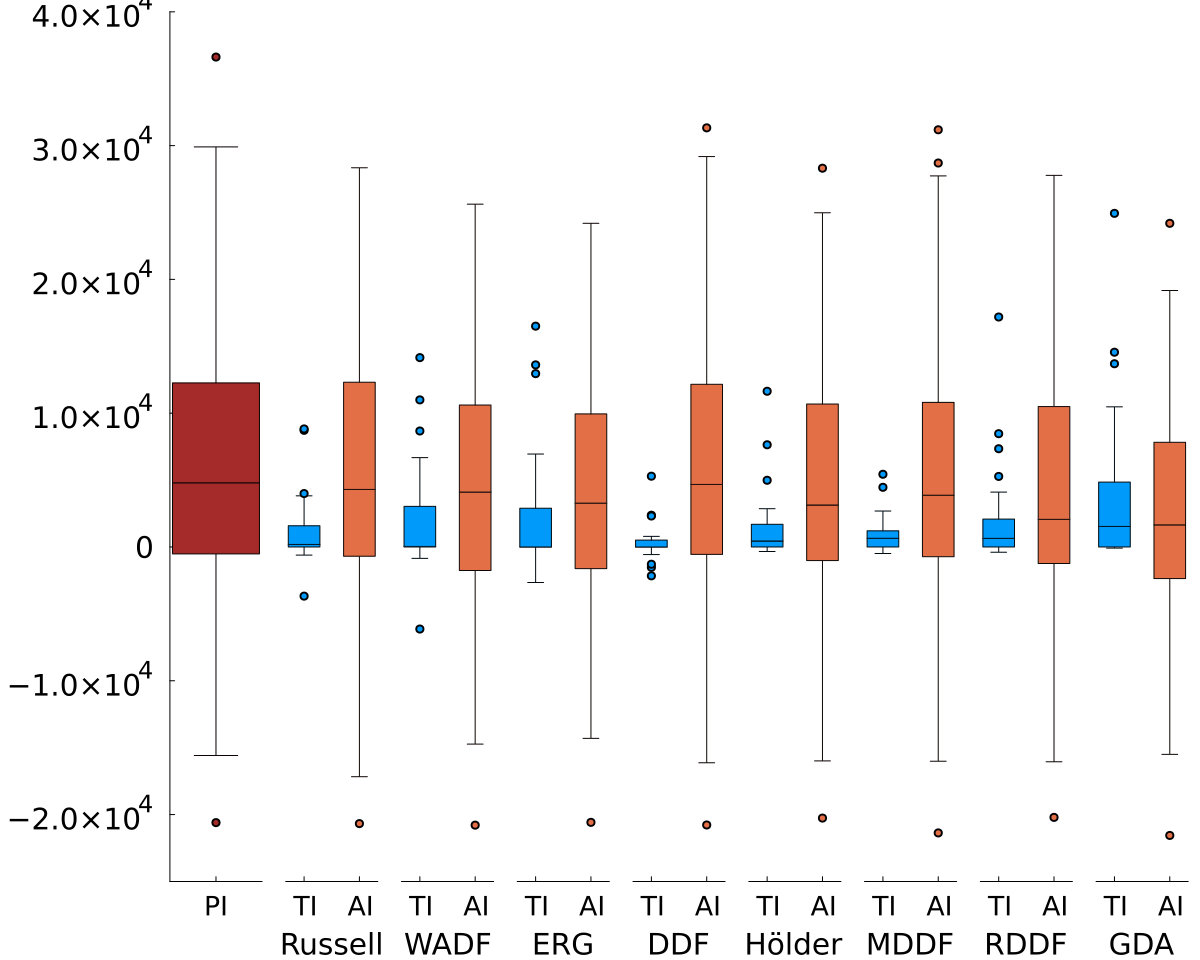

In [23]:
# Boxplot
l = @layout [a b c d e f g h i]
p0 = boxplot(["PI"], effchange(drussel, :Economic),
    xlabel = "",  grid = false, legend = false, color = "brown",
    titlelocation = :right)
p1 = boxplot(["TI" "AI"], [effchange(drussel, :Technical), effchange(drussel, :Allocative)],
    yaxis = false,  yticks = false, grid = false, legend = false,
    xlabel = "Russell",  titlelocation = :right)
p2 = boxplot(["TI" "AI"], [effchange(dadd, :Technical), effchange(dadd, :Allocative)],
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "WADF", titlelocation = :right)
p3 = boxplot(["TI" "AI"], [effchange(derg, :Technical), effchange(derg, :Allocative)],
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "ERG", titlelocation = :right)
p4 = boxplot(["TI" "AI"], [effchange(dddf, :Technical), effchange(dddf, :Allocative)],
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "DDF", titlelocation = :right)
p5 = boxplot(["TI" "AI"], [effchange(dholder, :Technical), effchange(dholder, :Allocative)], 
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "Hölder", titlelocation = :right)
p6 = boxplot(["TI" "AI"], [effchange(dmddf, :Technical), effchange(dmddf, :Allocative)], 
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "MDDF", titlelocation = :right)
p7 = boxplot(["TI" "AI"], [effchange(drddf, :Technical), effchange(drddf, :Allocative)], 
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "RDDF", titlelocation = :right)
p8 = boxplot(["TI" "AI"], [effchange(dgda, :Technical), effchange(dgda, :Allocative)], 
    yaxis = false, yticks = false, grid = false, legend = false,
    xlabel = "GDA", titlelocation = :right)
# legend = :topright, foreground_color_legend = nothing,     labels = ["Technical" " Allocative"],
plot(p0, p1, p2, p3, p4, p5, p6, p7, p8, layout = l, ylims = (-25000, 40000), size=(600 * 2, 400 * 2.4),
     xtickfontsize = 18, ytickfontsize = 20, guidefontsize = 20, legendfont = 20)


In [24]:
# Export figure
savefig("boxplot.png");

In [25]:
# Export data to Excel file
allresults = hcat(effchange(drussel), 
    effchange(dadd), 
    effchange(derg), 
    effchange(dddf),
    effchange(dholder),
    effchange(dmddf),
    effchange(drddf),
    effchange(dgda));

dfAllresults = DataFrame([banks allresults], ["Bank", "Russell", "WADF", "ERG", "DDF", "Holder", "MDDF", "RDDF", "GDA"])

XLSX.writetable("ProfitChange.xlsx", 
    PI =( collect(DataFrames.eachcol(dfAllresults)), DataFrames.names(dfAllresults) ),
    overwrite = true);